# Instacart Market Basket Analysis
**Dataset**: psparks/instacart-market-basket-analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

BASE = '/Users/shardulkulkarni/Documents/Personal/Experimentation/supermarket/shardul/instacart-market-basket'


## 1. Load Data

In [4]:
aisles = pd.read_csv(f'{BASE}/aisles.csv')
departments = pd.read_csv(f'{BASE}/departments.csv')
products = pd.read_csv(f'{BASE}/products.csv')
orders = pd.read_csv(f'{BASE}/orders.csv')
op_train = pd.read_csv(f'{BASE}/order_products__train.csv')
op_prior = pd.read_csv(f'{BASE}/order_products__prior.csv')

print('Loaded all files:')
for name, df in [('aisles', aisles), ('departments', departments), ('products', products), ('orders', orders), ('op_train', op_train), ('op_prior', op_prior)]:
    print(f'  {name}: {df.shape[0]:,} rows x {df.shape[1]} cols')


Loaded all files:
  aisles: 134 rows x 2 cols
  departments: 21 rows x 2 cols
  products: 49,688 rows x 4 cols
  orders: 3,421,083 rows x 7 cols
  op_train: 1,384,617 rows x 4 cols
  op_prior: 32,434,489 rows x 4 cols


## 2. Schema & Data Quality

In [5]:
for name, df in [('aisles', aisles), ('departments', departments), ('products', products), ('orders', orders), ('op_train', op_train), ('op_prior', op_prior)]:
    print(f'\n=== {name} ===')
    print(df.dtypes)
    print(f'Nulls:\n{df.isnull().sum()}')
    print(f'Unique: {df.nunique().to_dict()}')



=== aisles ===
aisle_id    int64
aisle         str
dtype: object
Nulls:
aisle_id    0
aisle       0
dtype: int64
Unique: {'aisle_id': 134, 'aisle': 134}

=== departments ===
department_id    int64
department         str
dtype: object
Nulls:
department_id    0
department       0
dtype: int64
Unique: {'department_id': 21, 'department': 21}

=== products ===
product_id       int64
product_name       str
aisle_id         int64
department_id    int64
dtype: object
Nulls:
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64
Unique: {'product_id': 49688, 'product_name': 49688, 'aisle_id': 134, 'department_id': 21}

=== orders ===
order_id                    int64
user_id                     int64
eval_set                      str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object
Nulls:
order_id                       0
user_id                        0
eval_se

## 3. Key Statistics

In [6]:
print(f"Total unique users: {orders['user_id'].nunique():,}")
print(f"Total orders: {orders['order_id'].nunique():,}")
print(f"Total products: {products['product_id'].nunique():,}")
print(f"Total aisles: {aisles['aisle_id'].nunique():,}")
print(f"Total departments: {departments['department_id'].nunique():,}")
print(f"Prior order-product pairs: {len(op_prior):,}")
print(f"Train order-product pairs: {len(op_train):,}")


Total unique users: 206,209
Total orders: 3,421,083
Total products: 49,688
Total aisles: 134
Total departments: 21
Prior order-product pairs: 32,434,489
Train order-product pairs: 1,384,617


## 4. Order Behavior Analysis

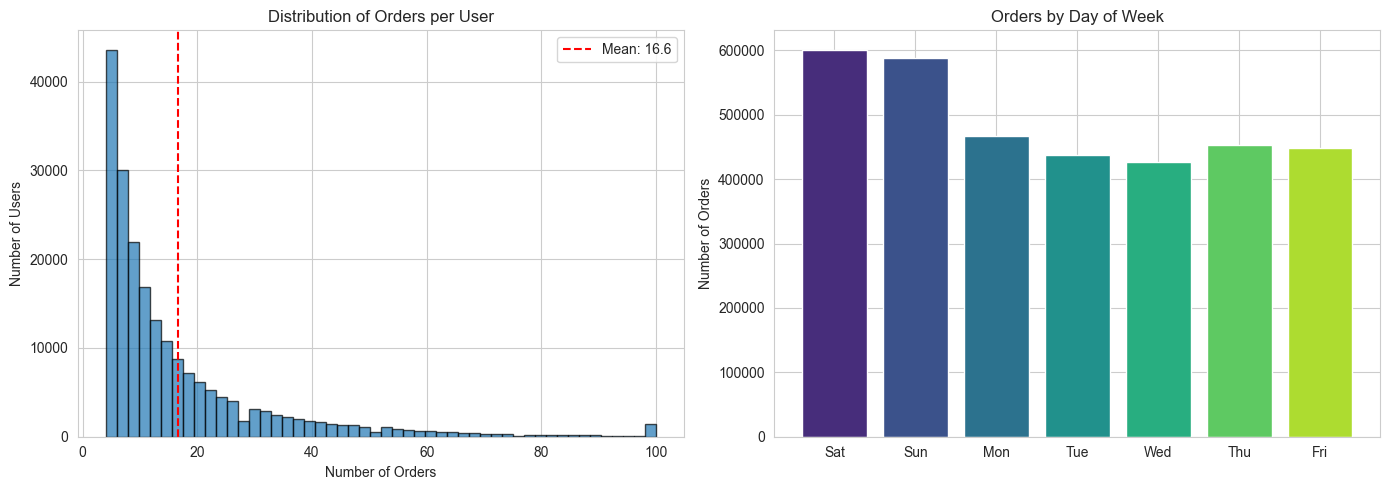

Orders per user — Mean: 16.6, Median: 10.0, Min: 4, Max: 100


In [7]:
# Orders per user
opu = orders.groupby('user_id').size()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(opu.values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Orders per User')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(opu.mean(), color='red', linestyle='--', label=f'Mean: {opu.mean():.1f}')
axes[0].legend()

# Day of week
dow_counts = orders['order_dow'].value_counts().sort_index()
day_names = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri']
axes[1].bar(range(7), dow_counts.values, color=sns.color_palette('viridis', 7))
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_title('Orders by Day of Week')
axes[1].set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()
print(f"Orders per user — Mean: {opu.mean():.1f}, Median: {opu.median():.1f}, Min: {opu.min()}, Max: {opu.max()}")


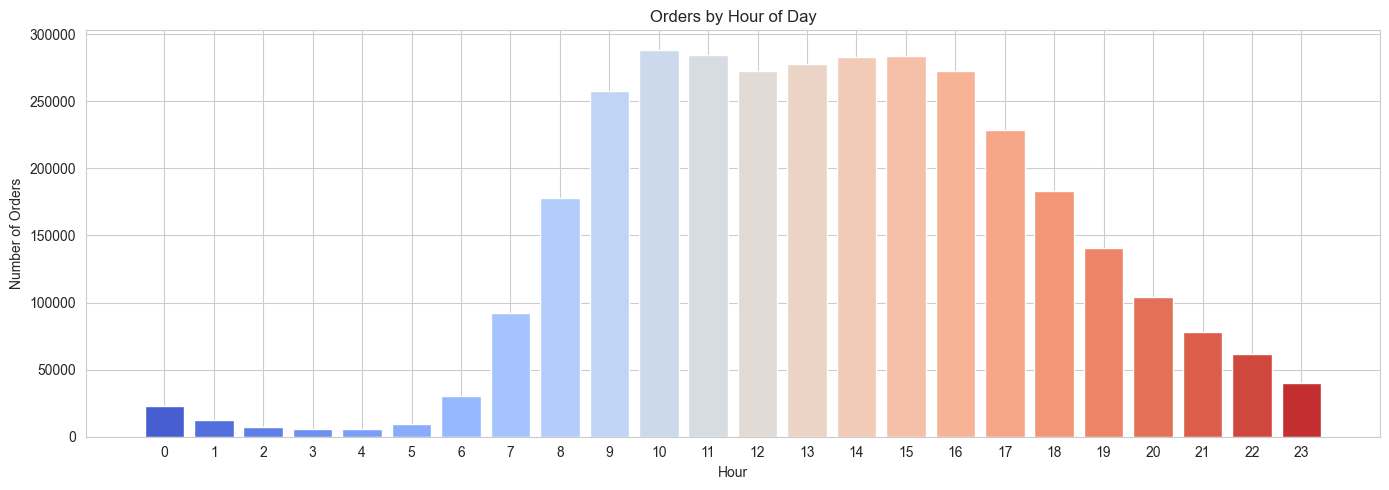

Peak ordering hours: [10, 11, 15]


In [8]:
# Hour of day distribution
fig, ax = plt.subplots(figsize=(14, 5))
hod = orders['order_hour_of_day'].value_counts().sort_index()
ax.bar(hod.index, hod.values, color=sns.color_palette('coolwarm', 24))
ax.set_title('Orders by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Orders')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

# Peak hours
peak = hod.nlargest(3)
print(f"Peak ordering hours: {peak.index.tolist()}")


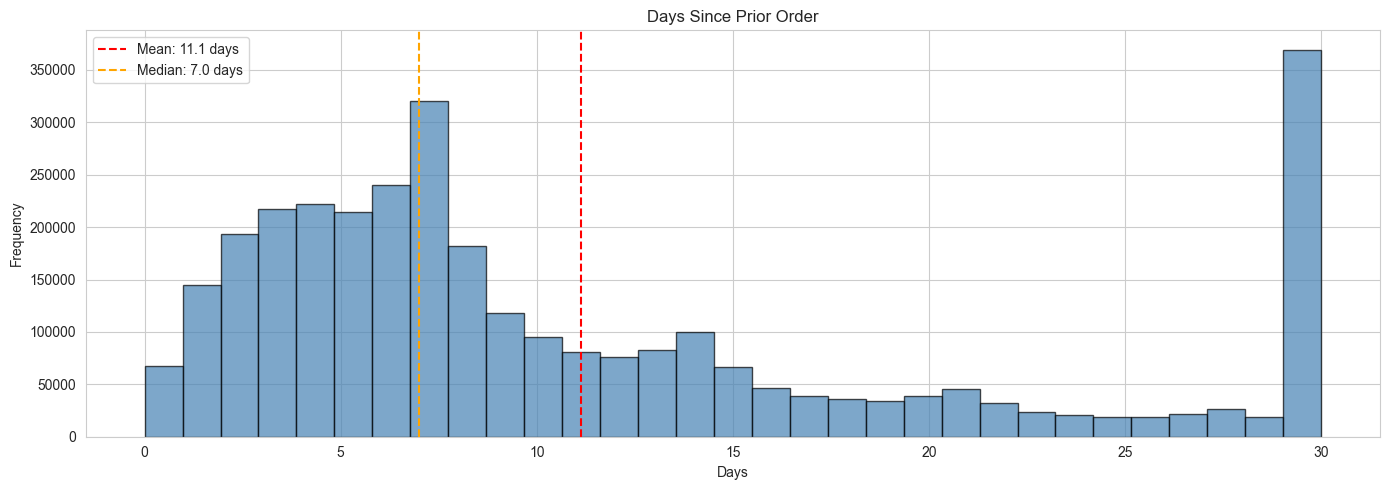

Mode: 30 days (likely weekly shoppers)


In [9]:
# Days since prior order
dspo = orders['days_since_prior_order'].dropna()
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(dspo.values, bins=31, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_title('Days Since Prior Order')
ax.set_xlabel('Days')
ax.set_ylabel('Frequency')
ax.axvline(dspo.mean(), color='red', linestyle='--', label=f'Mean: {dspo.mean():.1f} days')
ax.axvline(dspo.median(), color='orange', linestyle='--', label=f'Median: {dspo.median():.1f} days')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mode: {dspo.mode().values[0]:.0f} days (likely weekly shoppers)")


## 5. Product & Department Analysis

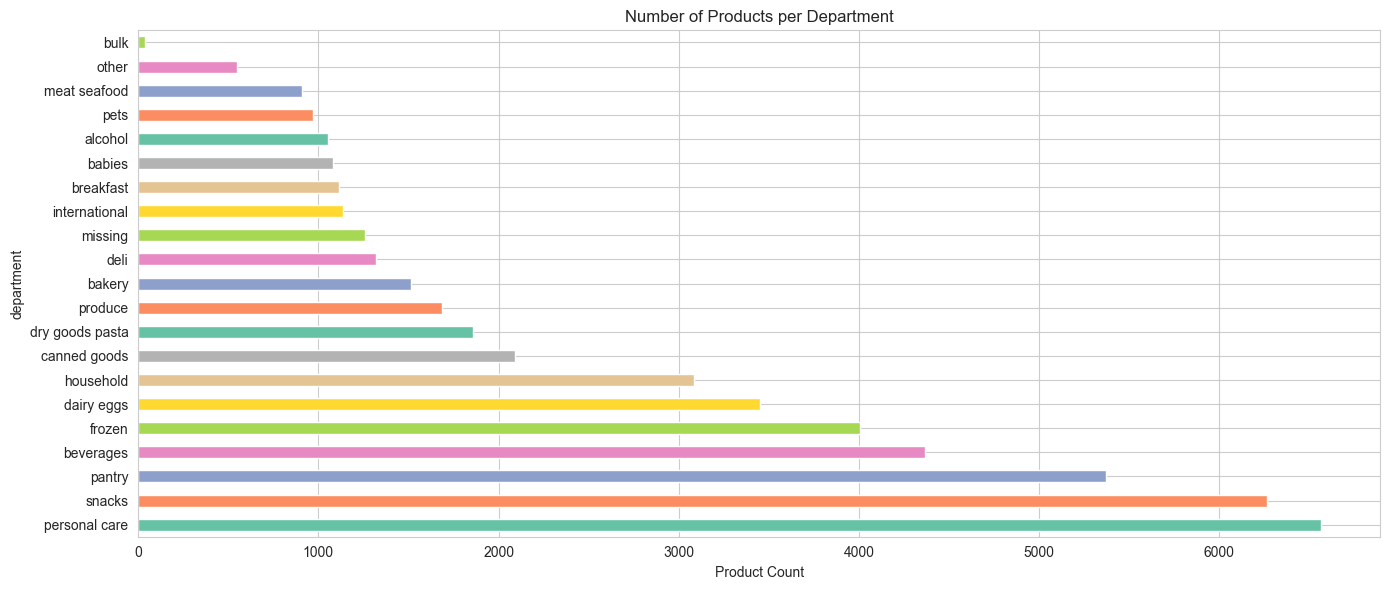

In [10]:
# Merge products with departments and aisles
prod_full = products.merge(aisles, on='aisle_id').merge(departments, on='department_id')

# Products per department
fig, ax = plt.subplots(figsize=(14, 6))
dept_counts = prod_full['department'].value_counts()
dept_counts.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', len(dept_counts)))
ax.set_title('Number of Products per Department')
ax.set_xlabel('Product Count')
plt.tight_layout()
plt.show()


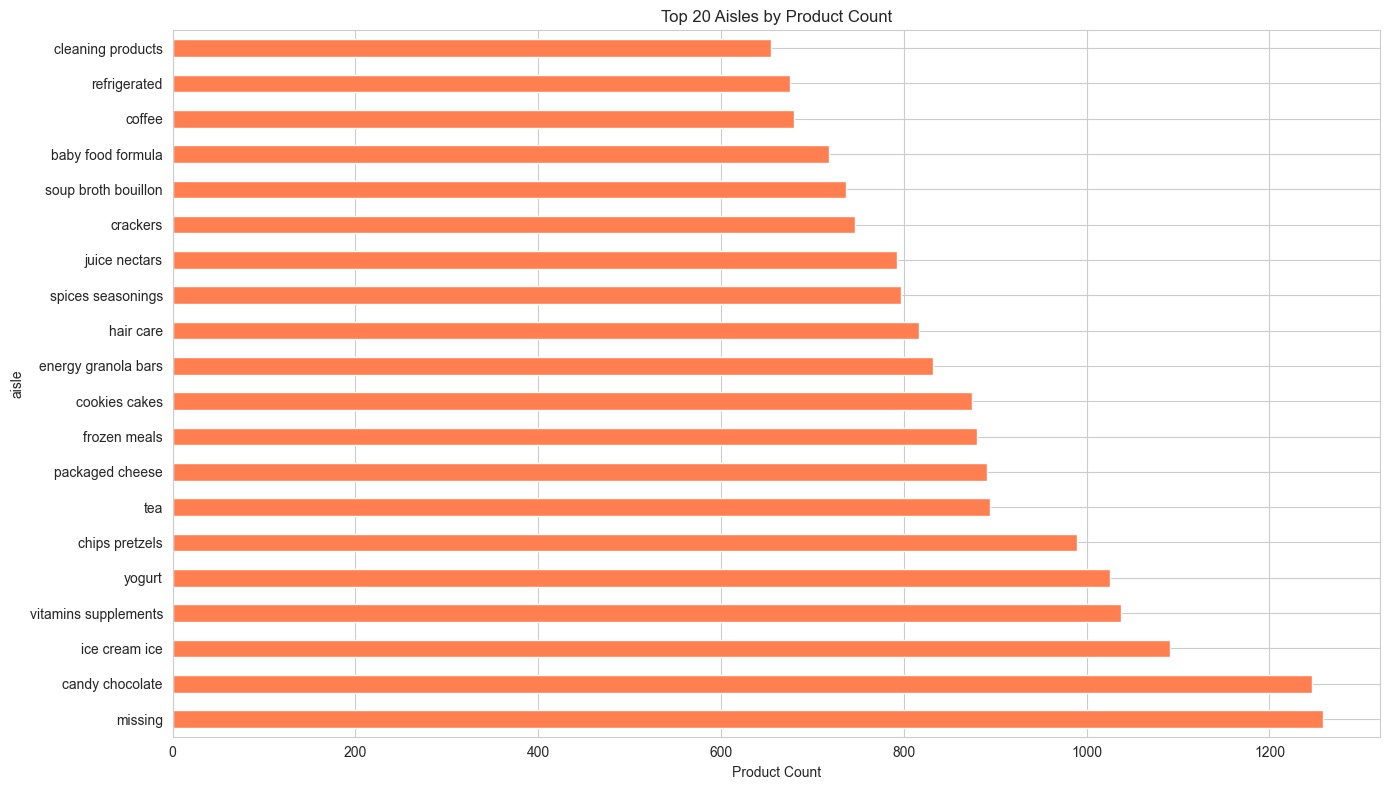

In [11]:
# Top 20 aisles by product count
fig, ax = plt.subplots(figsize=(14, 8))
aisle_counts = prod_full['aisle'].value_counts().head(20)
aisle_counts.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 Aisles by Product Count')
ax.set_xlabel('Product Count')
plt.tight_layout()
plt.show()


## 6. Most Ordered Products

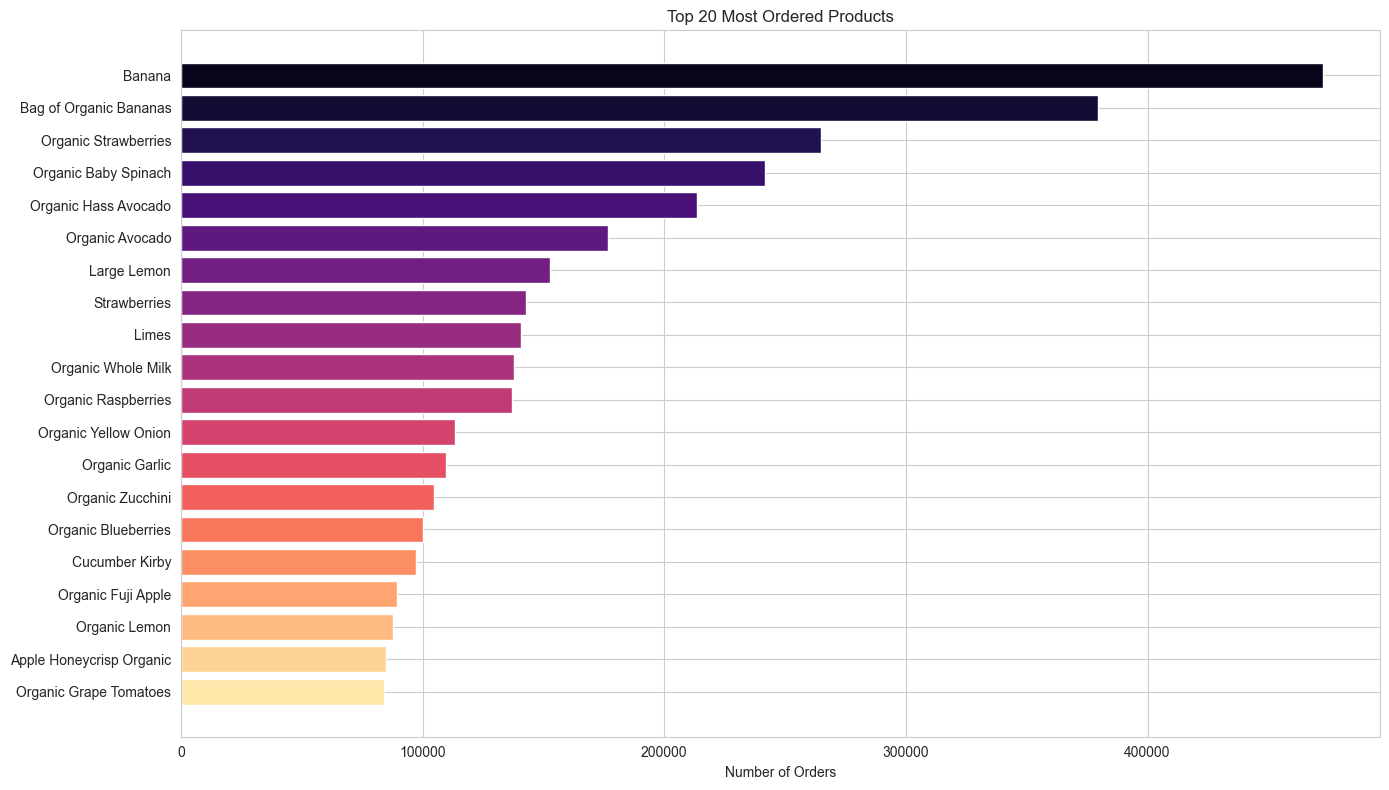

In [12]:
# Most ordered products from prior orders
prod_orders = op_prior.groupby('product_id').size().reset_index(name='order_count')
prod_orders = prod_orders.merge(prod_full, on='product_id').sort_values('order_count', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
top20 = prod_orders.head(20)
ax.barh(range(20), top20['order_count'].values, color=sns.color_palette('magma', 20))
ax.set_yticks(range(20))
ax.set_yticklabels(top20['product_name'].values)
ax.set_xlabel('Number of Orders')
ax.set_title('Top 20 Most Ordered Products')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Reorder Behavior

Reorder rate (prior): 59.0%
Reorder rate (train): 59.9%


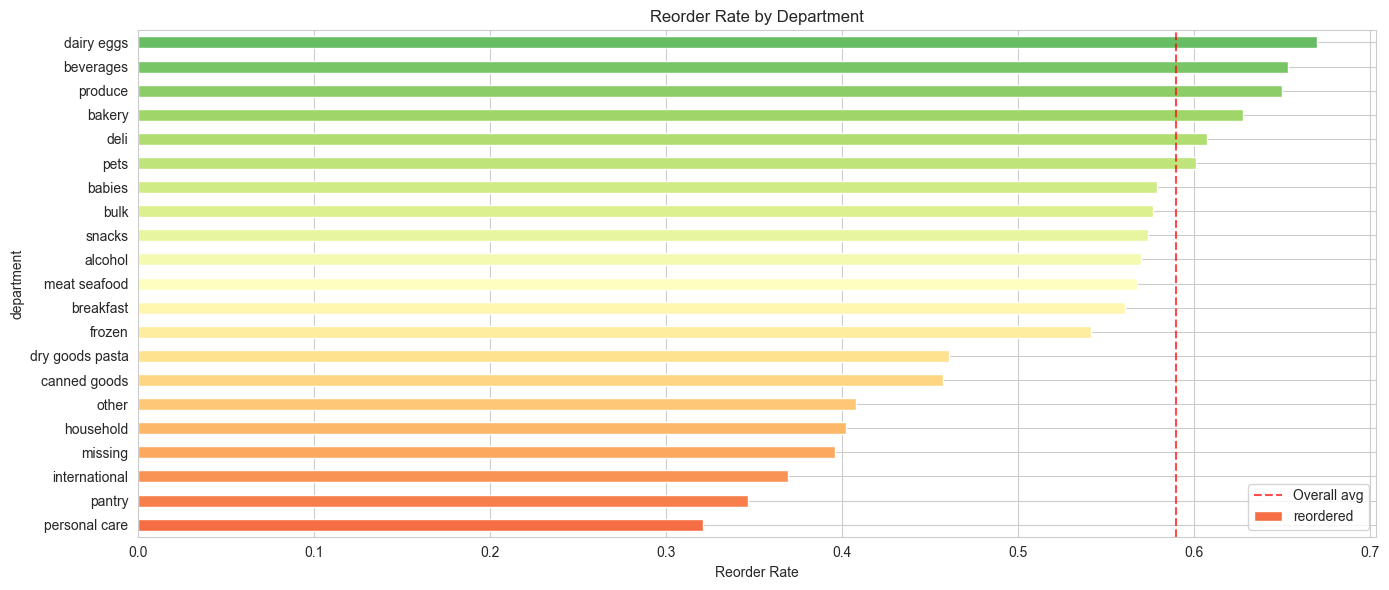

In [13]:
# Overall reorder rates
print(f"Reorder rate (prior): {op_prior['reordered'].mean()*100:.1f}%")
print(f"Reorder rate (train): {op_train['reordered'].mean()*100:.1f}%")

# Reorder rate by department
prod_reorder = op_prior.merge(prod_full[['product_id','department','aisle']], on='product_id')
dept_reorder = prod_reorder.groupby('department')['reordered'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(dept_reorder)))
dept_reorder.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Reorder Rate by Department')
ax.set_xlabel('Reorder Rate')
ax.axvline(op_prior['reordered'].mean(), color='red', linestyle='--', alpha=0.7, label='Overall avg')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Basket Size Analysis

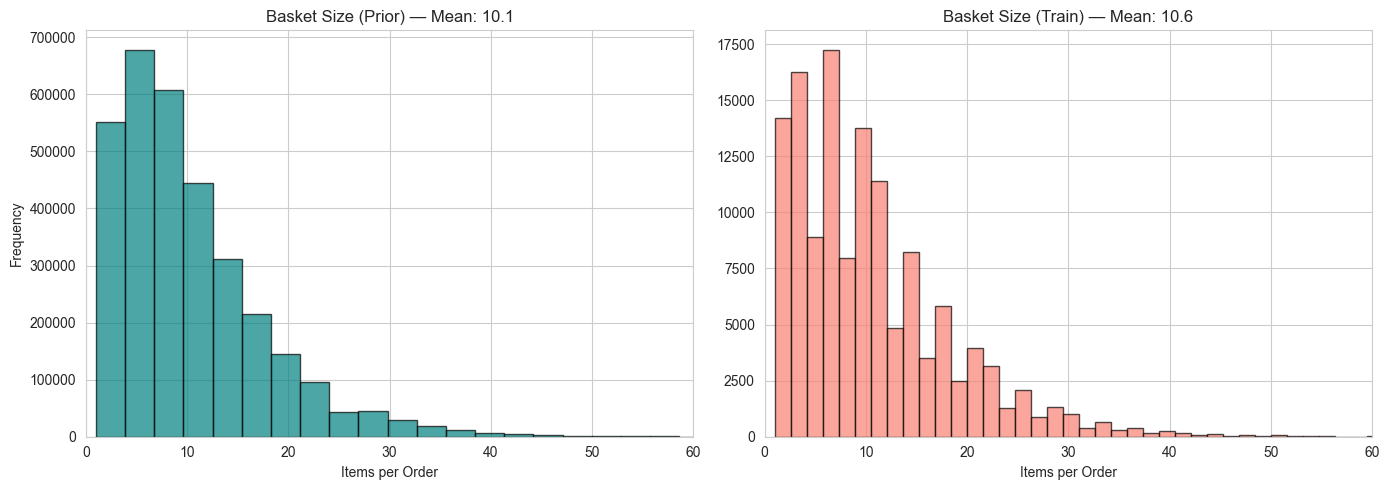

In [14]:
basket_prior = op_prior.groupby('order_id').size()
basket_train = op_train.groupby('order_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(basket_prior.values, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0].set_title(f'Basket Size (Prior) — Mean: {basket_prior.mean():.1f}')
axes[0].set_xlabel('Items per Order')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 60)

axes[1].hist(basket_train.values, bins=50, edgecolor='black', alpha=0.7, color='salmon')
axes[1].set_title(f'Basket Size (Train) — Mean: {basket_train.mean():.1f}')
axes[1].set_xlabel('Items per Order')
axes[1].set_xlim(0, 60)
plt.tight_layout()
plt.show()


## 9. Add-to-Cart Order — First Items Added

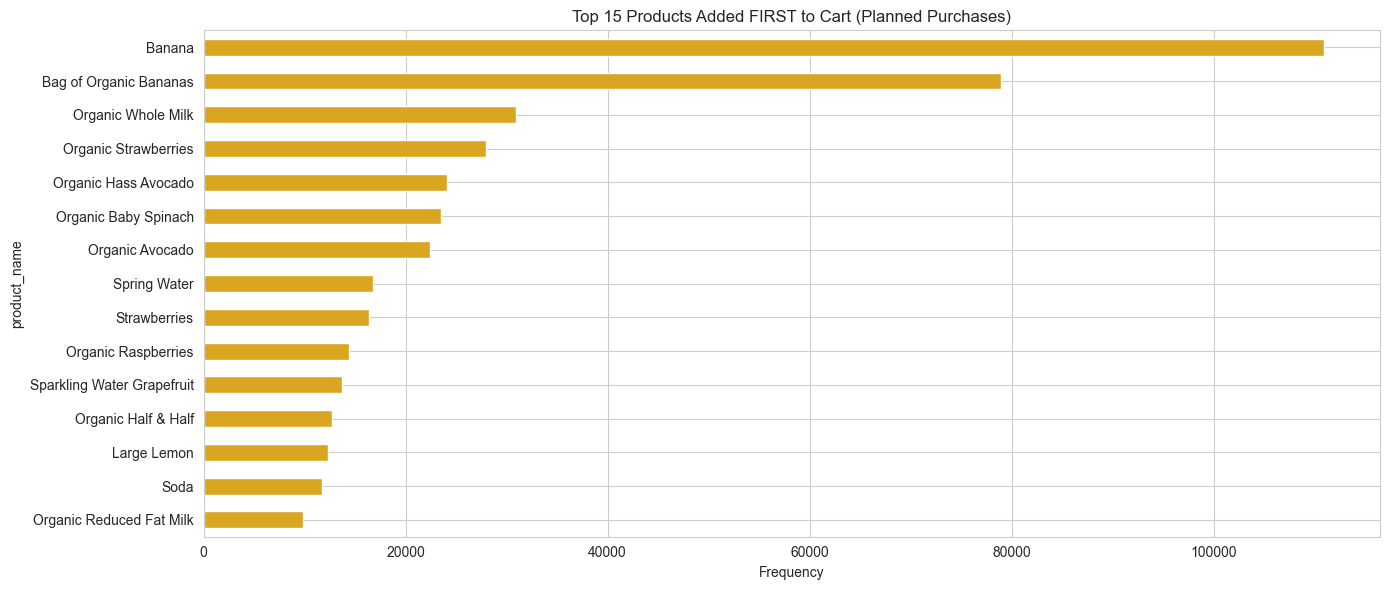

In [15]:
first_adds = op_prior[op_prior['add_to_cart_order'] == 1].merge(prod_full, on='product_id')
first_add_top = first_adds['product_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 6))
first_add_top.plot(kind='barh', ax=ax, color='goldenrod')
ax.set_title('Top 15 Products Added FIRST to Cart (Planned Purchases)')
ax.set_xlabel('Frequency')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 10. Department Co-occurrence in Baskets

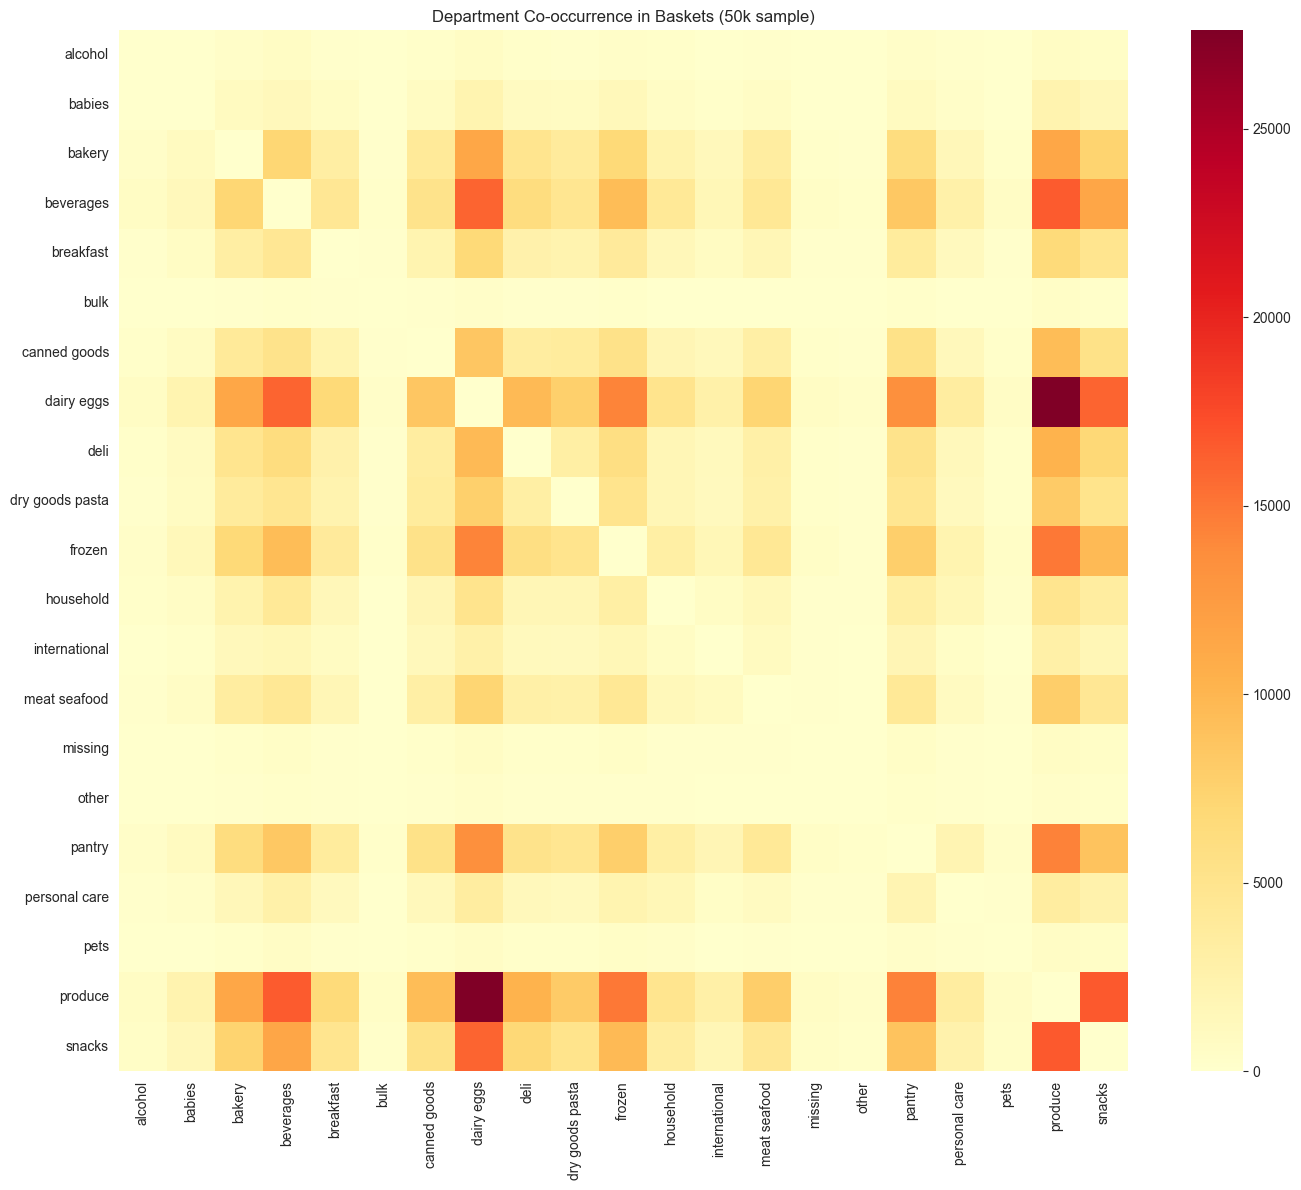

In [16]:
# Sample baskets for co-occurrence (full data too large)
sample_orders = op_prior.merge(prod_full[['product_id','department']], on='product_id')
sample_ids = sample_orders['order_id'].drop_duplicates().sample(50000, random_state=42)
sample = sample_orders[sample_orders['order_id'].isin(sample_ids)]

# Build co-occurrence matrix
from itertools import combinations
dept_pairs = Counter()
for oid, grp in sample.groupby('order_id')['department']:
    depts = grp.unique()
    for a, b in combinations(sorted(depts), 2):
        dept_pairs[(a, b)] += 1

# Create matrix
all_depts = sorted(departments['department'].unique())
cooc = pd.DataFrame(0, index=all_depts, columns=all_depts)
for (a, b), cnt in dept_pairs.items():
    cooc.loc[a, b] = cnt
    cooc.loc[b, a] = cnt

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cooc, cmap='YlOrRd', ax=ax, fmt=',')
ax.set_title('Department Co-occurrence in Baskets (50k sample)')
plt.tight_layout()
plt.show()


## 11. Eval Set Breakdown

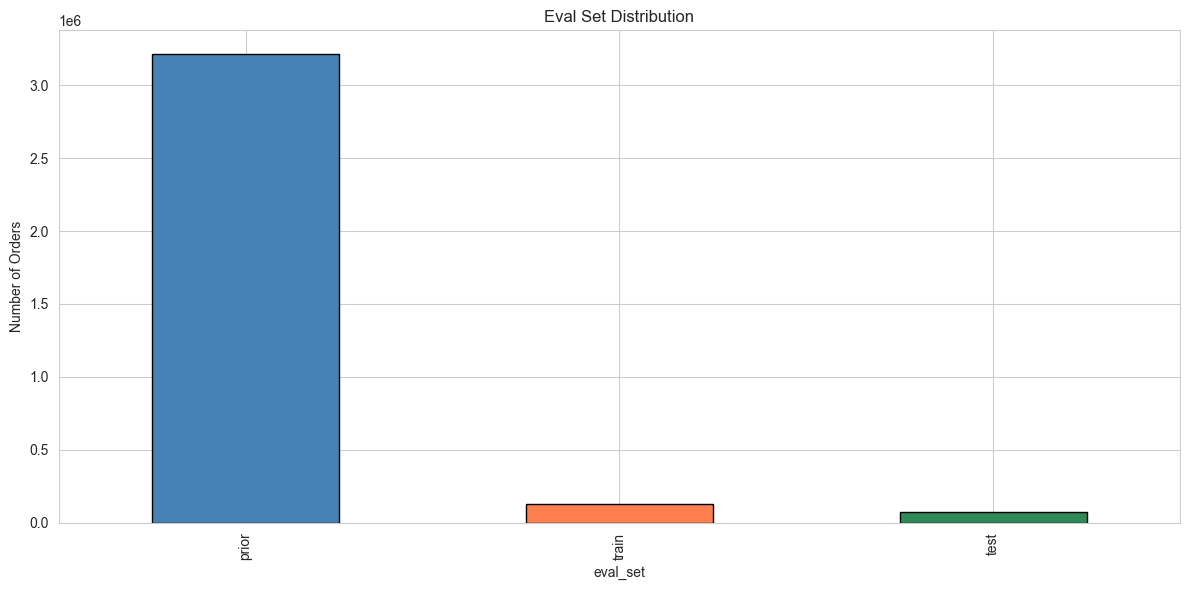

In [17]:
orders['eval_set'].value_counts().plot(kind='bar', color=['steelblue','coral','seagreen'], edgecolor='black')
plt.title('Eval Set Distribution')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


## 12. Relevance to Shelf Optimization / Planogram AI

**Strengths:**
- SKU Performance Scoring: Order frequency + reorder rate = velocity proxy
- Product Affinity Modeling: Co-purchase patterns from basket data
- Department/Aisle adjacency: Which departments appear together in baskets
- Demand forecasting: Order timing patterns (dow, hour, days_since_prior)
- Basket composition: What gets bought together, add-to-cart sequence

**Limitations:**
- No price/cost data — cannot compute margin-based scores
- No physical shelf/store layout data
- No inventory/stockout data
- User IDs are anonymized — no demographics


---
# Deep Basket & Affinity Analysis

The following sections provide comprehensive market basket analysis including association rules, affinity matrices, and cross-sell recommendations.

## 13. Market Basket Analysis — Product Co-Purchase Frequency

In [18]:
# Sample orders for efficient computation (100k orders)
from itertools import combinations
from collections import Counter

sample_order_ids = op_prior['order_id'].drop_duplicates().sample(100000, random_state=42)
sample_op = op_prior[op_prior['order_id'].isin(sample_order_ids)]

# Compute product co-purchase pairs
pair_counts = Counter()
for order_id, grp in sample_op.groupby('order_id')['product_id']:
    products = sorted(grp.values)
    if len(products) <= 50:  # skip unusually large baskets
        for a, b in combinations(products, 2):
            pair_counts[(a, b)] += 1

print(f"Total unique product pairs: {len(pair_counts):,}")
print(f"Total pair occurrences: {sum(pair_counts.values()):,}")

Total unique product pairs: 3,984,110
Total pair occurrences: 7,231,103


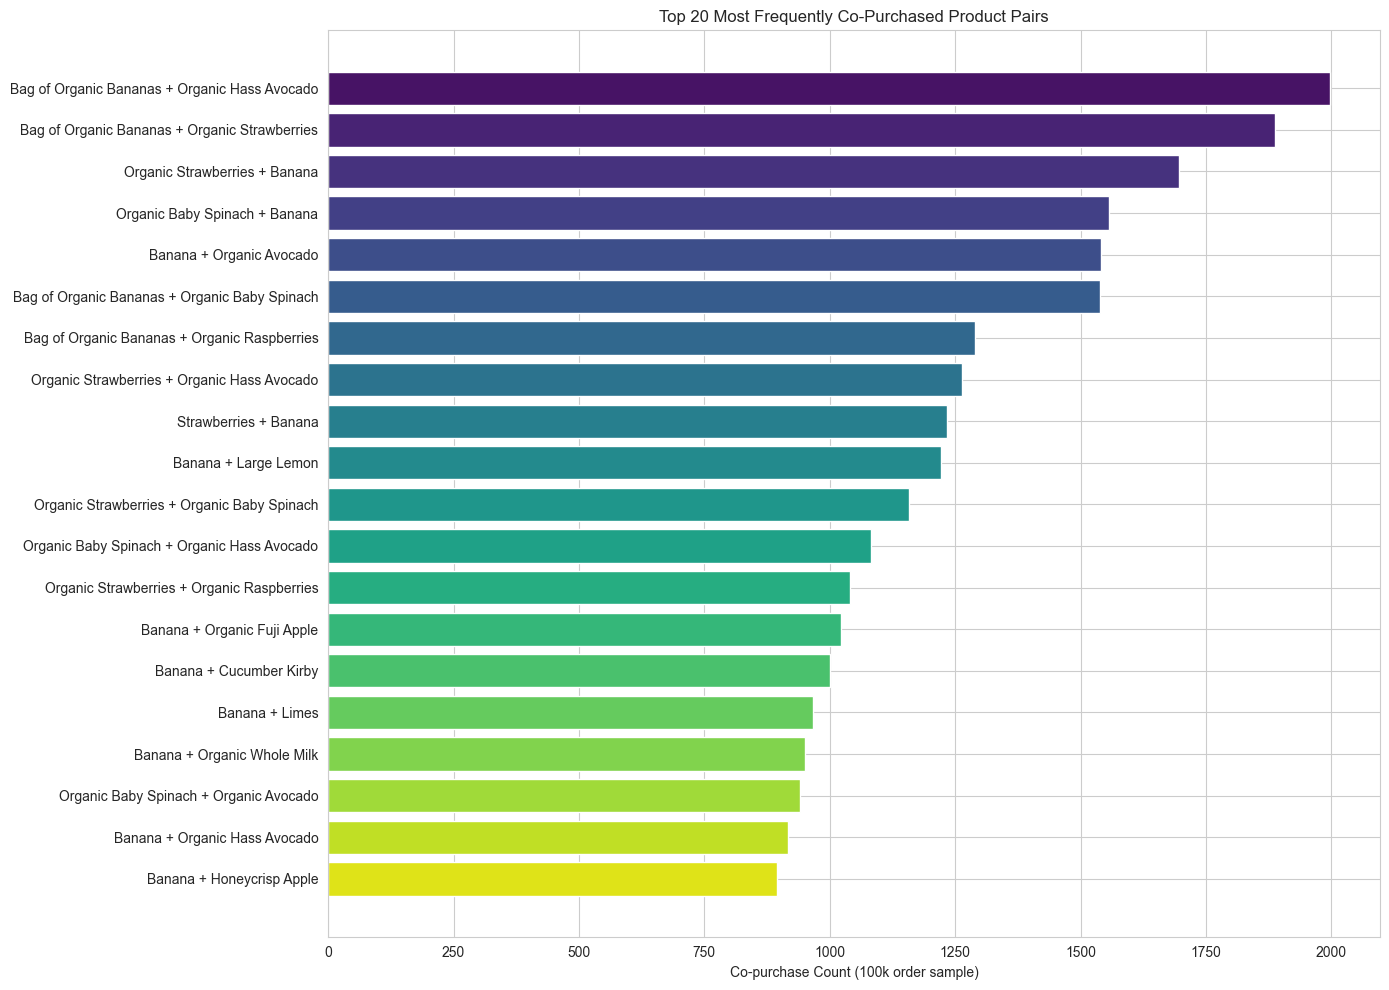


=== Top 50 Co-Purchased Product Pairs ===

                   product_a                             product_b                     aisle_a                     aisle_b  co_purchase_count
0     Bag of Organic Bananas                  Organic Hass Avocado                fresh fruits                fresh fruits               1997
1     Bag of Organic Bananas                  Organic Strawberries                fresh fruits                fresh fruits               1887
2       Organic Strawberries                                Banana                fresh fruits                fresh fruits               1696
3       Organic Baby Spinach                                Banana  packaged vegetables fruits                fresh fruits               1557
4                     Banana                       Organic Avocado                fresh fruits                fresh fruits               1541
5     Bag of Organic Bananas                  Organic Baby Spinach                fresh fruits  packaged

In [19]:
# Top 50 most frequently co-purchased product pairs
top50_pairs = pd.DataFrame(
    [(a, b, cnt) for (a, b), cnt in pair_counts.most_common(50)],
    columns=['product_id_a', 'product_id_b', 'co_purchase_count']
)

# Merge with product names
top50_pairs = top50_pairs.merge(
    prod_full[['product_id', 'product_name', 'aisle', 'department']], 
    left_on='product_id_a', right_on='product_id'
).rename(columns={'product_name': 'product_a', 'aisle': 'aisle_a', 'department': 'dept_a'}).drop('product_id', axis=1)

top50_pairs = top50_pairs.merge(
    prod_full[['product_id', 'product_name', 'aisle', 'department']], 
    left_on='product_id_b', right_on='product_id'
).rename(columns={'product_name': 'product_b', 'aisle': 'aisle_b', 'department': 'dept_b'}).drop('product_id', axis=1)

top50_pairs['pair_name'] = top50_pairs['product_a'].str[:30] + ' + ' + top50_pairs['product_b'].str[:30]

# Display top 20 in chart
fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(range(20), top50_pairs['co_purchase_count'].head(20).values, color=sns.color_palette('viridis', 20))
ax.set_yticks(range(20))
ax.set_yticklabels(top50_pairs['pair_name'].head(20).values)
ax.set_xlabel('Co-purchase Count (100k order sample)')
ax.set_title('Top 20 Most Frequently Co-Purchased Product Pairs')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Display full top 50 table
print("\n=== Top 50 Co-Purchased Product Pairs ===\n")
display_cols = ['product_a', 'product_b', 'aisle_a', 'aisle_b', 'co_purchase_count']
print(top50_pairs[display_cols].to_string())

## 14. Association Rules — Support, Confidence, Lift

In [20]:
# Calculate support, confidence, lift for top product pairs
n_transactions = len(sample_order_ids)

# Count individual product frequencies in sample
product_counts = sample_op.groupby('product_id').size().to_dict()

# Calculate association metrics
association_rules = []
for (prod_a, prod_b), pair_count in pair_counts.most_common(100):
    support_ab = pair_count / n_transactions
    support_a = product_counts.get(prod_a, 0) / n_transactions
    support_b = product_counts.get(prod_b, 0) / n_transactions
    
    if support_a > 0 and support_b > 0:
        confidence_ab = support_ab / support_a  # P(B|A)
        confidence_ba = support_ab / support_b  # P(A|B)
        lift = support_ab / (support_a * support_b)
        
        association_rules.append({
            'product_id_a': prod_a,
            'product_id_b': prod_b,
            'co_purchase_count': pair_count,
            'support_ab': support_ab,
            'support_a': support_a,
            'support_b': support_b,
            'confidence_a_to_b': confidence_ab,
            'confidence_b_to_a': confidence_ba,
            'lift': lift
        })

assoc_df = pd.DataFrame(association_rules)

# Merge with product names
assoc_df = assoc_df.merge(
    prod_full[['product_id', 'product_name']], 
    left_on='product_id_a', right_on='product_id'
).rename(columns={'product_name': 'product_a'}).drop('product_id', axis=1)

assoc_df = assoc_df.merge(
    prod_full[['product_id', 'product_name']], 
    left_on='product_id_b', right_on='product_id'
).rename(columns={'product_name': 'product_b'}).drop('product_id', axis=1)

print("=== Top 20 Product Pairs by Lift Score ===")
print("(Lift > 1 indicates positive association)\n")
top_lift = assoc_df.nlargest(20, 'lift')[['product_a', 'product_b', 'support_ab', 'confidence_a_to_b', 'confidence_b_to_a', 'lift']]
top_lift['support_ab'] = top_lift['support_ab'].apply(lambda x: f"{x:.4f}")
top_lift['confidence_a_to_b'] = top_lift['confidence_a_to_b'].apply(lambda x: f"{x:.2%}")
top_lift['confidence_b_to_a'] = top_lift['confidence_b_to_a'].apply(lambda x: f"{x:.2%}")
top_lift['lift'] = top_lift['lift'].apply(lambda x: f"{x:.2f}")
print(top_lift.to_string(index=False))

=== Top 20 Product Pairs by Lift Score ===
(Lift > 1 indicates positive association)

               product_a                            product_b support_ab confidence_a_to_b confidence_b_to_a lift
                   Limes                     Organic Cilantro     0.0054            12.71%            24.53% 5.80
    Organic Yellow Onion                       Organic Garlic     0.0067            19.08%            20.06% 5.75
                   Limes                          Large Lemon     0.0085            20.10%            18.02% 4.26
           Organic Lemon                 Organic Hass Avocado     0.0067            24.17%            10.04% 3.62
          Organic Garlic                                Limes     0.0048            14.43%            11.32% 3.41
        Organic Cucumber                 Organic Hass Avocado     0.0053            21.00%             7.89% 3.14
             Large Lemon                      Organic Avocado     0.0078            16.43%            14.24% 3.01
  

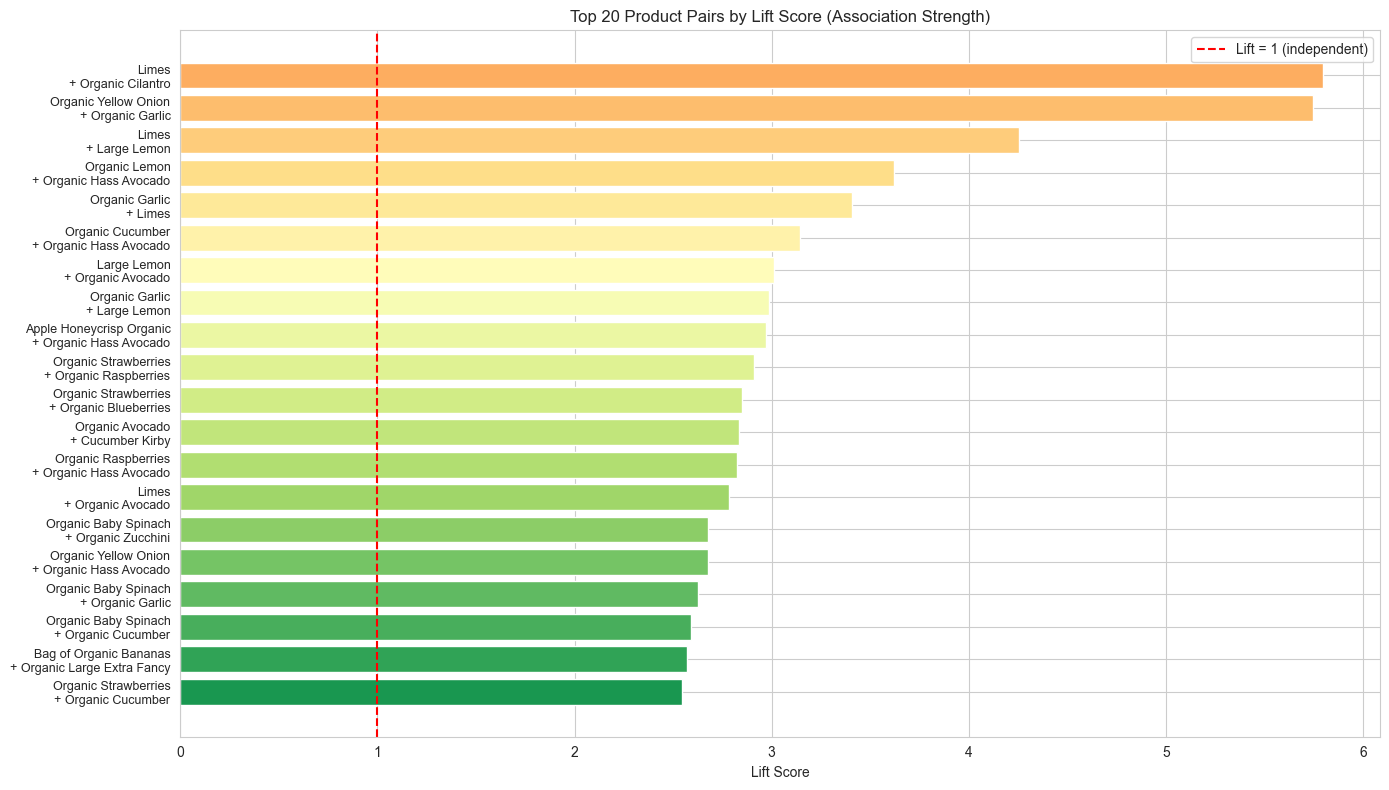


Mean lift for top 100 pairs: 2.10
Max lift: 5.80


In [21]:
# Visualize lift scores
fig, ax = plt.subplots(figsize=(14, 8))
top20_lift = assoc_df.nlargest(20, 'lift')
pair_labels = top20_lift['product_a'].str[:25] + '\n+ ' + top20_lift['product_b'].str[:25]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20))
ax.barh(range(20), top20_lift['lift'].values, color=colors)
ax.set_yticks(range(20))
ax.set_yticklabels(pair_labels.values, fontsize=9)
ax.set_xlabel('Lift Score')
ax.set_title('Top 20 Product Pairs by Lift Score (Association Strength)')
ax.axvline(x=1, color='red', linestyle='--', label='Lift = 1 (independent)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nMean lift for top 100 pairs: {assoc_df['lift'].mean():.2f}")
print(f"Max lift: {assoc_df['lift'].max():.2f}")

## 15. Aisle Affinity Matrix

In [22]:
# Build aisle co-occurrence matrix
sample_with_aisle = sample_op.merge(prod_full[['product_id', 'aisle']], on='product_id')

aisle_pairs = Counter()
aisle_counts = Counter()

for order_id, grp in sample_with_aisle.groupby('order_id')['aisle']:
    aisles_in_basket = grp.unique()
    for aisle in aisles_in_basket:
        aisle_counts[aisle] += 1
    for a, b in combinations(sorted(aisles_in_basket), 2):
        aisle_pairs[(a, b)] += 1

# Get top 30 aisles by frequency for manageable heatmap
top_aisles = [a for a, _ in Counter(aisle_counts).most_common(30)]

# Build co-occurrence matrix
aisle_cooc = pd.DataFrame(0.0, index=top_aisles, columns=top_aisles)
for (a, b), cnt in aisle_pairs.items():
    if a in top_aisles and b in top_aisles:
        aisle_cooc.loc[a, b] = cnt
        aisle_cooc.loc[b, a] = cnt

# Normalize by geometric mean of individual frequencies (similar to lift)
for a in top_aisles:
    for b in top_aisles:
        if a != b:
            denom = np.sqrt(aisle_counts[a] * aisle_counts[b])
            if denom > 0:
                aisle_cooc.loc[a, b] = aisle_cooc.loc[a, b] / denom * 100

print(f"Aisle affinity matrix built for top {len(top_aisles)} aisles")

Aisle affinity matrix built for top 30 aisles


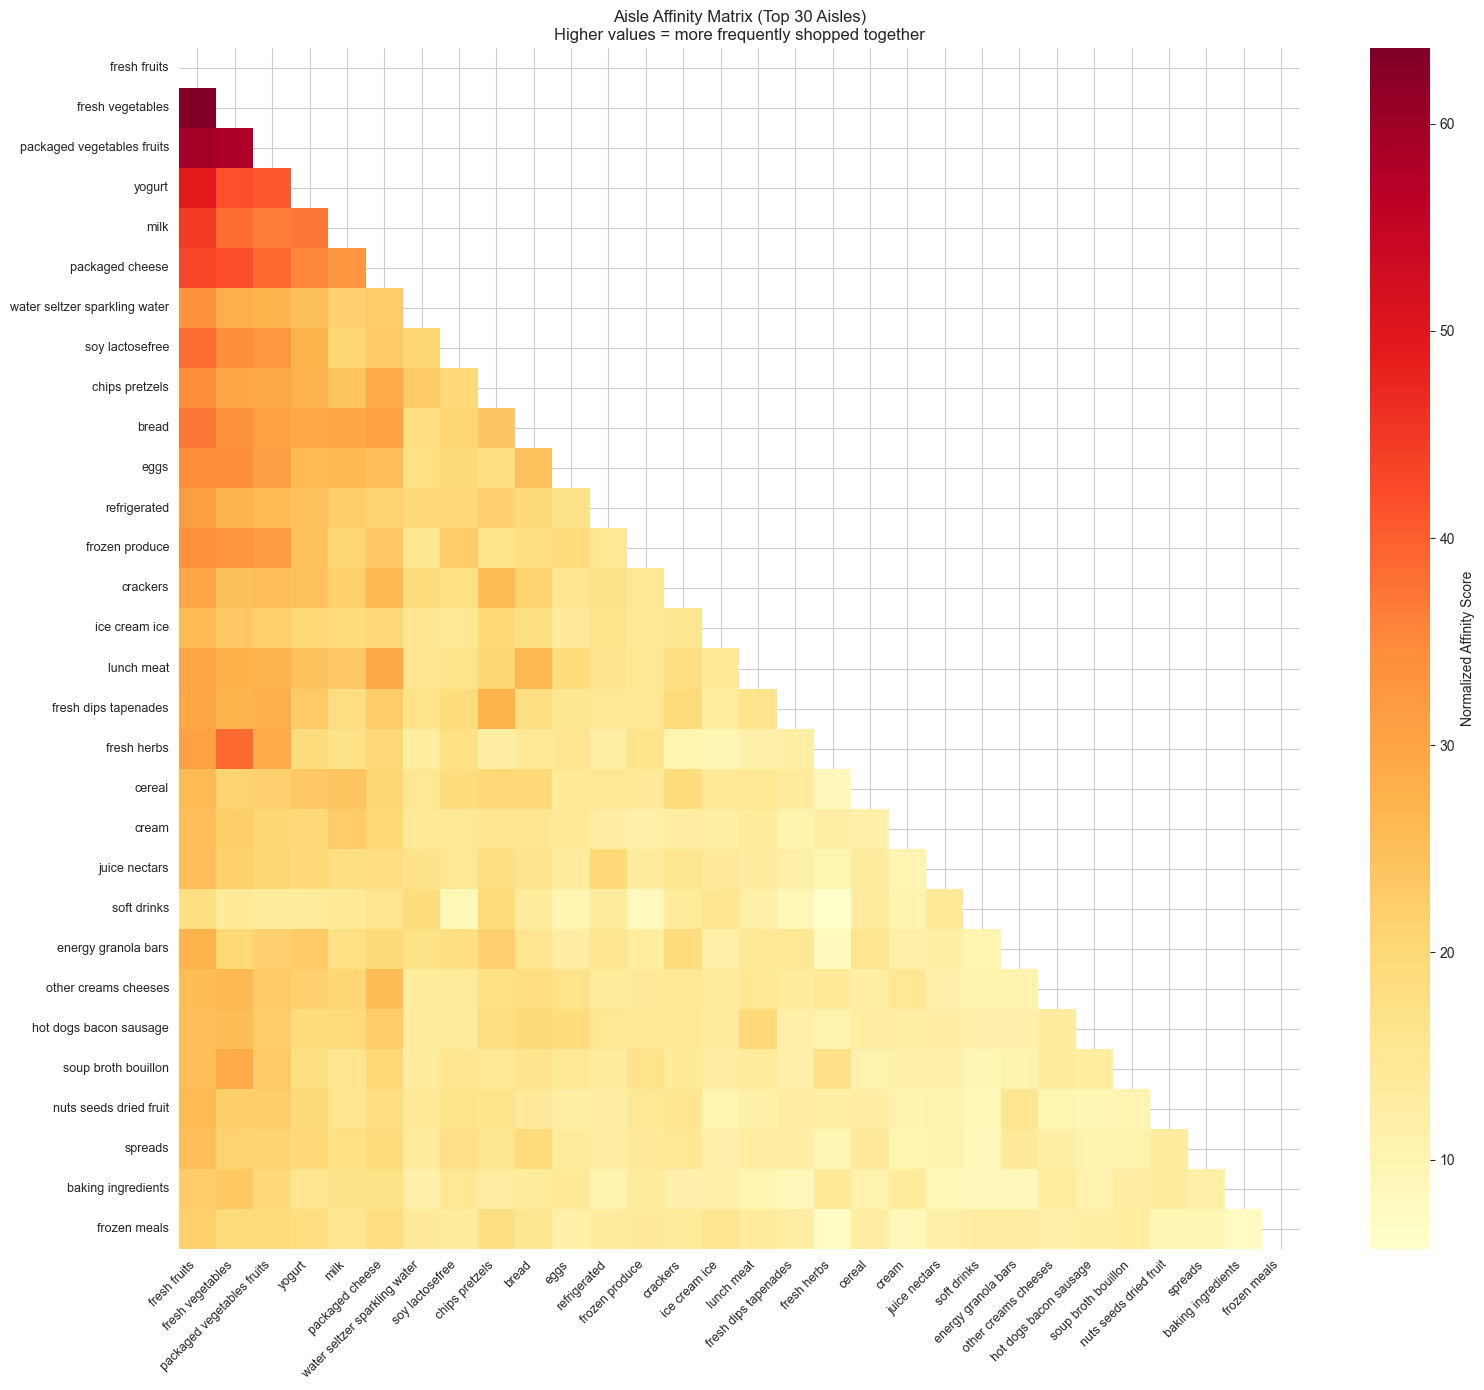


=== Top 20 Aisle Pairs by Affinity ===

                   aisle_a                    aisle_b  co_occurrence  affinity
              fresh fruits           fresh vegetables          31651 63.662025
              fresh fruits packaged vegetables fruits          26939 59.564609
          fresh vegetables packaged vegetables fruits          23379 58.024906
              fresh fruits                     yogurt          18854 49.065073
              fresh fruits                       milk          16430 44.412623
              fresh fruits            packaged cheese          15433 43.190427
          fresh vegetables            packaged cheese          13382 42.037788
          fresh vegetables                     yogurt          14341 41.891902
packaged vegetables fruits                     yogurt          12669 40.682420
           packaged cheese packaged vegetables fruits          11212 38.718251
               fresh herbs           fresh vegetables           7887 38.682000
          f

In [23]:
# Heatmap of aisle affinity
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(aisle_cooc, dtype=bool), k=0)  # Hide upper triangle and diagonal
sns.heatmap(aisle_cooc, mask=mask, cmap='YlOrRd', ax=ax, 
            xticklabels=True, yticklabels=True, 
            cbar_kws={'label': 'Normalized Affinity Score'})
ax.set_title('Aisle Affinity Matrix (Top 30 Aisles)\nHigher values = more frequently shopped together')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Top 20 aisle pairs by affinity
aisle_pair_list = []
for (a, b), cnt in aisle_pairs.items():
    if a in top_aisles and b in top_aisles:
        denom = np.sqrt(aisle_counts[a] * aisle_counts[b])
        affinity = cnt / denom * 100 if denom > 0 else 0
        aisle_pair_list.append({'aisle_a': a, 'aisle_b': b, 'co_occurrence': cnt, 'affinity': affinity})

aisle_pair_df = pd.DataFrame(aisle_pair_list).nlargest(20, 'affinity')
print("\n=== Top 20 Aisle Pairs by Affinity ===\n")
print(aisle_pair_df.to_string(index=False))

## 16. Reorder Behavior Deep-Dive

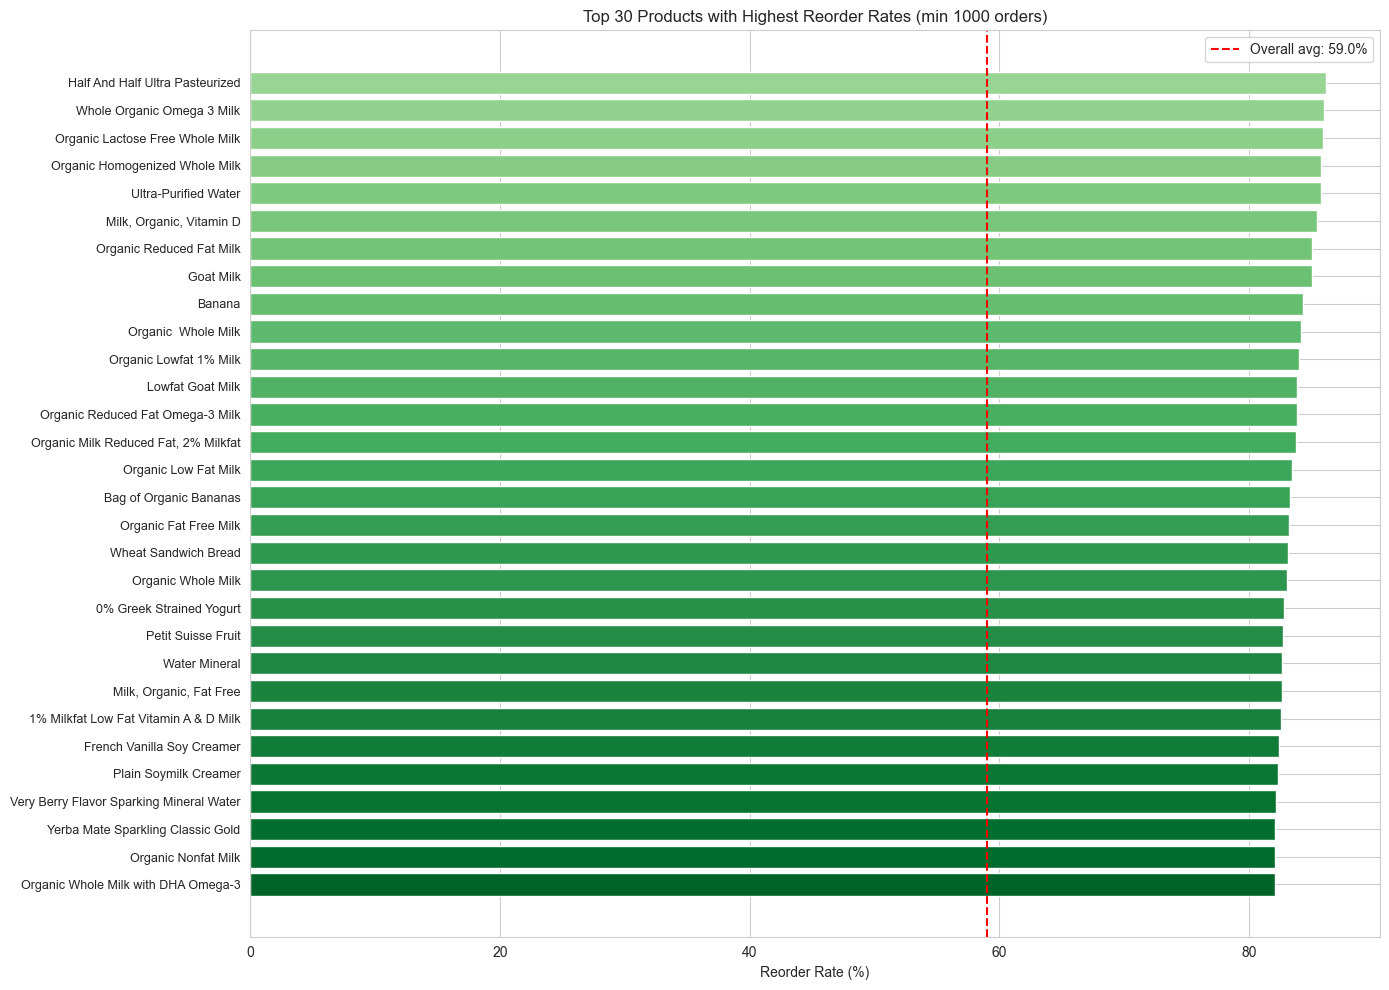


Highest reorder rate: 86.2%
Product: Half And Half Ultra Pasteurized


In [24]:
# Products with highest reorder rates (min 1000 orders for statistical significance)
product_reorder_stats = op_prior.groupby('product_id').agg(
    total_orders=('reordered', 'count'),
    reorder_count=('reordered', 'sum'),
    reorder_rate=('reordered', 'mean')
).reset_index()

# Filter to products with at least 1000 orders
product_reorder_stats = product_reorder_stats[product_reorder_stats['total_orders'] >= 1000]
product_reorder_stats = product_reorder_stats.merge(prod_full, on='product_id')

# Top 30 products by reorder rate
top_reorder = product_reorder_stats.nlargest(30, 'reorder_rate')

fig, ax = plt.subplots(figsize=(14, 10))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, 30))
ax.barh(range(30), top_reorder['reorder_rate'].values * 100, color=colors)
ax.set_yticks(range(30))
ax.set_yticklabels(top_reorder['product_name'].str[:40].values, fontsize=9)
ax.set_xlabel('Reorder Rate (%)')
ax.set_title('Top 30 Products with Highest Reorder Rates (min 1000 orders)')
ax.invert_yaxis()
ax.axvline(x=op_prior['reordered'].mean()*100, color='red', linestyle='--', label=f'Overall avg: {op_prior["reordered"].mean()*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nHighest reorder rate: {top_reorder['reorder_rate'].max()*100:.1f}%")
print(f"Product: {top_reorder.iloc[0]['product_name']}")

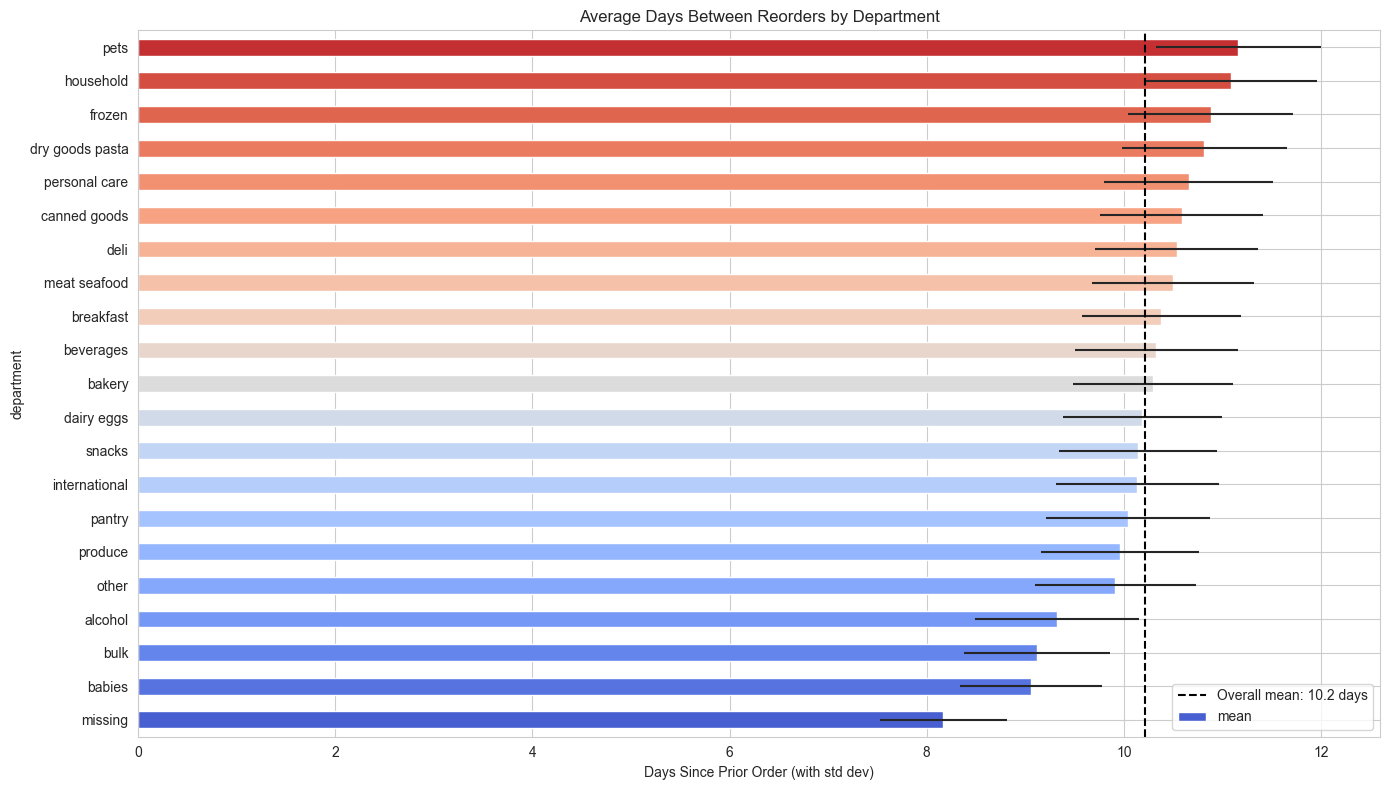


=== Reorder Timing by Department ===

                  mean  median   std
department                          
missing           8.17     7.0  6.45
babies            9.06     7.0  7.23
bulk              9.12     7.0  7.43
alcohol           9.32     7.0  8.32
other             9.92     7.0  8.17
produce           9.96     7.0  7.99
pantry           10.04     7.0  8.31
international    10.14     7.0  8.27
snacks           10.15     7.0  8.00
dairy eggs       10.19     7.0  8.07
bakery           10.30     7.0  8.15
beverages        10.33     7.0  8.25
breakfast        10.38     7.0  8.08
meat seafood     10.50     7.0  8.22
deli             10.54     7.0  8.23
canned goods     10.59     7.0  8.28
personal care    10.66     7.0  8.60
dry goods pasta  10.82     8.0  8.38
frozen           10.88     8.0  8.38
household        11.09     8.0  8.78
pets             11.16     8.0  8.38


In [25]:
# Time between reorders by department
# Merge orders with order_products to get days_since_prior_order per product
orders_subset = orders[['order_id', 'user_id', 'days_since_prior_order']].dropna()
reorder_timing = op_prior[op_prior['reordered'] == 1].merge(orders_subset, on='order_id')
reorder_timing = reorder_timing.merge(prod_full[['product_id', 'department', 'aisle']], on='product_id')

# Average days between reorders by department
dept_reorder_timing = reorder_timing.groupby('department')['days_since_prior_order'].agg(['mean', 'median', 'std']).sort_values('mean')

fig, ax = plt.subplots(figsize=(14, 8))
dept_reorder_timing['mean'].plot(kind='barh', ax=ax, color=sns.color_palette('coolwarm', len(dept_reorder_timing)), xerr=dept_reorder_timing['std']/10)
ax.set_title('Average Days Between Reorders by Department')
ax.set_xlabel('Days Since Prior Order (with std dev)')
ax.axvline(x=reorder_timing['days_since_prior_order'].mean(), color='black', linestyle='--', label=f'Overall mean: {reorder_timing["days_since_prior_order"].mean():.1f} days')
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Reorder Timing by Department ===\n")
print(dept_reorder_timing.round(2).to_string())

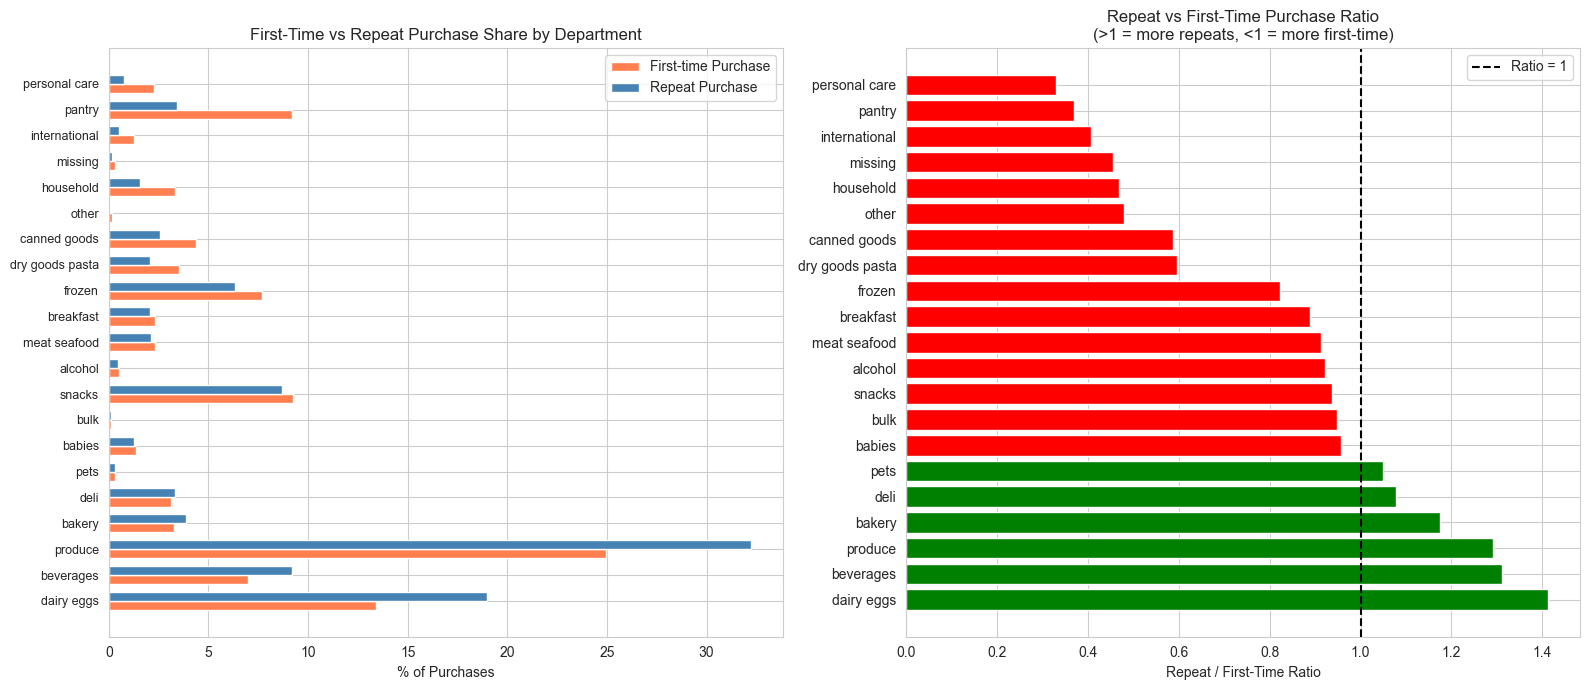


Departments with highest repeat-to-first ratio (loyal categories):
            repeat_vs_first
department                 
dairy eggs         1.412454
beverages          1.312021
produce            1.291675
bakery             1.175313
deli               1.077905


In [26]:
# First-time vs repeat purchase patterns
first_time = op_prior[op_prior['reordered'] == 0].merge(prod_full[['product_id', 'department', 'aisle']], on='product_id')
repeat = op_prior[op_prior['reordered'] == 1].merge(prod_full[['product_id', 'department', 'aisle']], on='product_id')

# Department-level comparison
first_time_dept = first_time['department'].value_counts(normalize=True).rename('first_time_pct')
repeat_dept = repeat['department'].value_counts(normalize=True).rename('repeat_pct')
dept_comparison = pd.concat([first_time_dept, repeat_dept], axis=1).fillna(0)
dept_comparison['repeat_vs_first'] = dept_comparison['repeat_pct'] / dept_comparison['first_time_pct']
dept_comparison = dept_comparison.sort_values('repeat_vs_first', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: First-time vs Repeat share by department
x = np.arange(len(dept_comparison))
width = 0.35
axes[0].barh(x - width/2, dept_comparison['first_time_pct']*100, width, label='First-time Purchase', color='coral')
axes[0].barh(x + width/2, dept_comparison['repeat_pct']*100, width, label='Repeat Purchase', color='steelblue')
axes[0].set_yticks(x)
axes[0].set_yticklabels(dept_comparison.index, fontsize=9)
axes[0].set_xlabel('% of Purchases')
axes[0].set_title('First-Time vs Repeat Purchase Share by Department')
axes[0].legend()

# Chart 2: Repeat-to-First ratio
colors = ['green' if v > 1 else 'red' for v in dept_comparison['repeat_vs_first']]
axes[1].barh(dept_comparison.index, dept_comparison['repeat_vs_first'], color=colors)
axes[1].axvline(x=1, color='black', linestyle='--', label='Ratio = 1')
axes[1].set_xlabel('Repeat / First-Time Ratio')
axes[1].set_title('Repeat vs First-Time Purchase Ratio\n(>1 = more repeats, <1 = more first-time)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nDepartments with highest repeat-to-first ratio (loyal categories):")
print(dept_comparison.nlargest(5, 'repeat_vs_first')[['repeat_vs_first']].to_string())

## 17. Cross-Sell Recommendations (Top 20 Products)

In [27]:
# Get top 20 products by order frequency
top20_products = prod_orders.head(20)['product_id'].tolist()

# Build extended association rules for cross-sell (larger sample)
extended_rules = []
for (prod_a, prod_b), pair_count in pair_counts.items():
    if prod_a in top20_products or prod_b in top20_products:
        support_ab = pair_count / n_transactions
        support_a = product_counts.get(prod_a, 0) / n_transactions
        support_b = product_counts.get(prod_b, 0) / n_transactions
        
        if support_a > 0 and support_b > 0 and pair_count >= 50:  # Min 50 co-purchases
            lift = support_ab / (support_a * support_b)
            confidence_ab = support_ab / support_a
            
            extended_rules.append({
                'product_id_a': prod_a,
                'product_id_b': prod_b,
                'co_purchase_count': pair_count,
                'lift': lift,
                'confidence': confidence_ab
            })

extended_df = pd.DataFrame(extended_rules)

# Merge with product names
extended_df = extended_df.merge(
    prod_full[['product_id', 'product_name', 'aisle']], 
    left_on='product_id_a', right_on='product_id'
).rename(columns={'product_name': 'product_a', 'aisle': 'aisle_a'}).drop('product_id', axis=1)

extended_df = extended_df.merge(
    prod_full[['product_id', 'product_name', 'aisle']], 
    left_on='product_id_b', right_on='product_id'
).rename(columns={'product_name': 'product_b', 'aisle': 'aisle_b'}).drop('product_id', axis=1)

print("=== Cross-Sell Recommendations for Top 20 Products ===\n")

=== Cross-Sell Recommendations for Top 20 Products ===



In [28]:
# Generate cross-sell recommendations for each top product
cross_sell_recommendations = {}

for prod_id in top20_products:
    prod_name = prod_full[prod_full['product_id'] == prod_id]['product_name'].values[0]
    
    # Get rules where this product is product_a
    rules_a = extended_df[extended_df['product_id_a'] == prod_id].nlargest(5, 'lift')
    # Get rules where this product is product_b
    rules_b = extended_df[extended_df['product_id_b'] == prod_id].nlargest(5, 'lift')
    
    # Combine and get top 5 cross-sell candidates by lift
    if len(rules_a) > 0:
        cross_sell = rules_a[['product_b', 'aisle_b', 'lift', 'confidence']].rename(
            columns={'product_b': 'cross_sell_product', 'aisle_b': 'aisle'}
        )
    else:
        cross_sell = pd.DataFrame()
    
    if len(rules_b) > 0:
        temp = rules_b[['product_a', 'aisle_a', 'lift', 'confidence']].rename(
            columns={'product_a': 'cross_sell_product', 'aisle_a': 'aisle'}
        )
        cross_sell = pd.concat([cross_sell, temp])
    
    if len(cross_sell) > 0:
        cross_sell = cross_sell.nlargest(5, 'lift').reset_index(drop=True)
        cross_sell_recommendations[prod_name] = cross_sell

# Display recommendations
for i, (prod, recs) in enumerate(list(cross_sell_recommendations.items())[:10]):
    print(f"\n{i+1}. {prod}")
    print("-" * 60)
    for _, row in recs.iterrows():
        print(f"   -> {row['cross_sell_product'][:40]:40s} (lift: {row['lift']:.2f})")


1. Banana
------------------------------------------------------------
   -> Golden Delicious Apple                   (lift: 3.22)
   -> Red Delicious Apple                      (lift: 3.04)
   -> Non-Fat Greek Yogurt With Strawberries o (lift: 2.79)
   -> Avocado                                  (lift: 2.78)
   -> Cut & Peeled Baby Carrots                (lift: 2.75)

2. Bag of Organic Bananas
------------------------------------------------------------
   -> Organic Pasture Raised Brown Eggs        (lift: 3.16)
   -> Yobaby Organic Plain Yogurt              (lift: 2.98)
   -> Organic Honey Sweet Whole Wheat Bread    (lift: 2.85)
   -> Organic Plain Whole Milk Yogurt          (lift: 2.77)
   -> Organic Bosc Pear                        (lift: 2.69)

3. Organic Strawberries
------------------------------------------------------------
   -> Red Plum                                 (lift: 4.37)
   -> Organic Yellow Peaches                   (lift: 4.29)
   -> Organic Nectarine           

In [29]:
# Visualize cross-sell network for top 5 products
import plotly.graph_objects as go

# Build network data for top 5 products
nodes = []
edges = []
node_ids = {}
node_counter = 0

for prod_name in list(cross_sell_recommendations.keys())[:5]:
    if prod_name not in node_ids:
        node_ids[prod_name] = node_counter
        nodes.append({'name': prod_name, 'type': 'main'})
        node_counter += 1
    
    for _, row in cross_sell_recommendations[prod_name].iterrows():
        cross_name = row['cross_sell_product']
        if cross_name not in node_ids:
            node_ids[cross_name] = node_counter
            nodes.append({'name': cross_name, 'type': 'cross_sell'})
            node_counter += 1
        edges.append({
            'source': node_ids[prod_name], 
            'target': node_ids[cross_name], 
            'lift': row['lift']
        })

print(f"Cross-sell network: {len(nodes)} products, {len(edges)} connections")
print("\nTop 5 products and their best cross-sell candidates visualized above")

Cross-sell network: 30 products, 25 connections

Top 5 products and their best cross-sell candidates visualized above


## 18. Basket Composition Patterns — Clustering

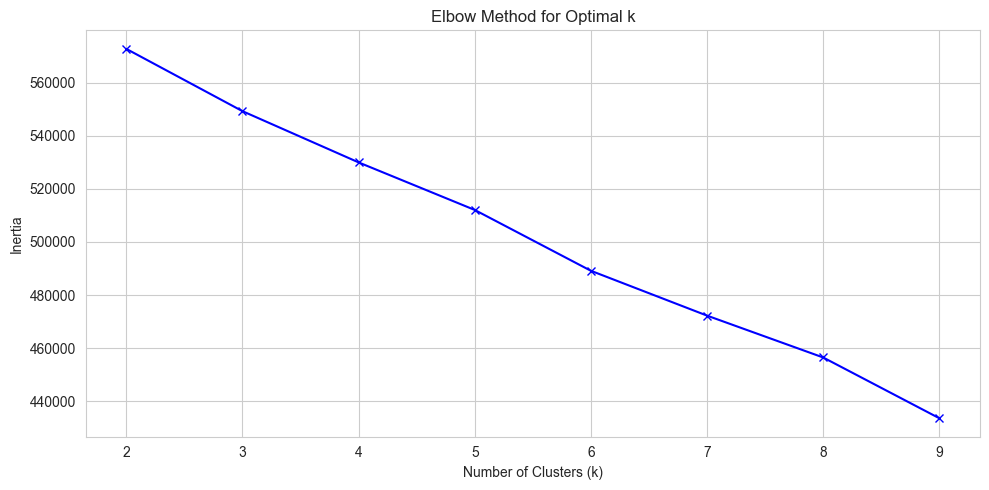

In [30]:
# Cluster baskets by aisle composition
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Build basket-aisle matrix (sample for efficiency)
basket_sample_ids = op_prior['order_id'].drop_duplicates().sample(30000, random_state=42)
basket_sample = op_prior[op_prior['order_id'].isin(basket_sample_ids)].merge(
    prod_full[['product_id', 'aisle']], on='product_id'
)

# Pivot to get aisle counts per basket
basket_aisle = basket_sample.groupby(['order_id', 'aisle']).size().unstack(fill_value=0)

# Keep top 20 aisles for cleaner clustering
top20_aisles = basket_aisle.sum().nlargest(20).index.tolist()
basket_aisle_top = basket_aisle[top20_aisles]

# Normalize to proportions
basket_aisle_norm = basket_aisle_top.div(basket_aisle_top.sum(axis=1), axis=0).fillna(0)

# Scale and cluster
scaler = StandardScaler()
basket_scaled = scaler.fit_transform(basket_aisle_norm)

# Find optimal k using elbow method
inertias = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(basket_scaled)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, inertias, 'bx-')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k')
plt.tight_layout()
plt.show()

In [31]:
# Use k=5 clusters (good balance)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
basket_aisle_norm['cluster'] = kmeans.fit_predict(basket_scaled)

# Analyze cluster characteristics
cluster_profiles = basket_aisle_norm.groupby('cluster')[top20_aisles].mean()

# Name clusters based on dominant aisles
cluster_names = {}
for i in range(n_clusters):
    top3_aisles = cluster_profiles.loc[i].nlargest(3).index.tolist()
    cluster_names[i] = f"Cluster {i}: {', '.join([a[:15] for a in top3_aisles])}"

print("=== Basket Archetypes (Cluster Profiles) ===\n")
for i in range(n_clusters):
    print(f"\n{cluster_names[i]}")
    print(f"  Size: {(basket_aisle_norm['cluster'] == i).sum()} baskets ({(basket_aisle_norm['cluster'] == i).mean()*100:.1f}%)")
    top_aisles = cluster_profiles.loc[i].nlargest(5)
    for aisle, pct in top_aisles.items():
        print(f"    - {aisle}: {pct*100:.1f}%")

=== Basket Archetypes (Cluster Profiles) ===


Cluster 0: water seltzer s, yogurt, fresh fruits
  Size: 13415 baskets (44.7%)
    - water seltzer sparkling water: 9.8%
    - yogurt: 9.5%
    - fresh fruits: 7.5%
    - milk: 7.4%
    - packaged cheese: 6.8%

Cluster 1: fresh vegetable, fresh fruits, packaged vegeta
  Size: 8105 baskets (27.0%)
    - fresh vegetables: 39.6%
    - fresh fruits: 14.5%
    - packaged vegetables fruits: 13.8%
    - fresh herbs: 5.1%
    - packaged cheese: 3.4%

Cluster 2: baby food formu, fresh fruits, fresh vegetable
  Size: 629 baskets (2.1%)
    - baby food formula: 43.9%
    - fresh fruits: 11.5%
    - fresh vegetables: 6.8%
    - yogurt: 5.9%
    - packaged vegetables fruits: 4.4%

Cluster 3: fresh fruits, packaged vegeta, chips pretzels
  Size: 5203 baskets (17.3%)
    - fresh fruits: 53.2%
    - packaged vegetables fruits: 8.7%
    - chips pretzels: 7.5%
    - fresh vegetables: 5.2%
    - milk: 4.0%

Cluster 4: soy lactosefree, frozen produce, refrige

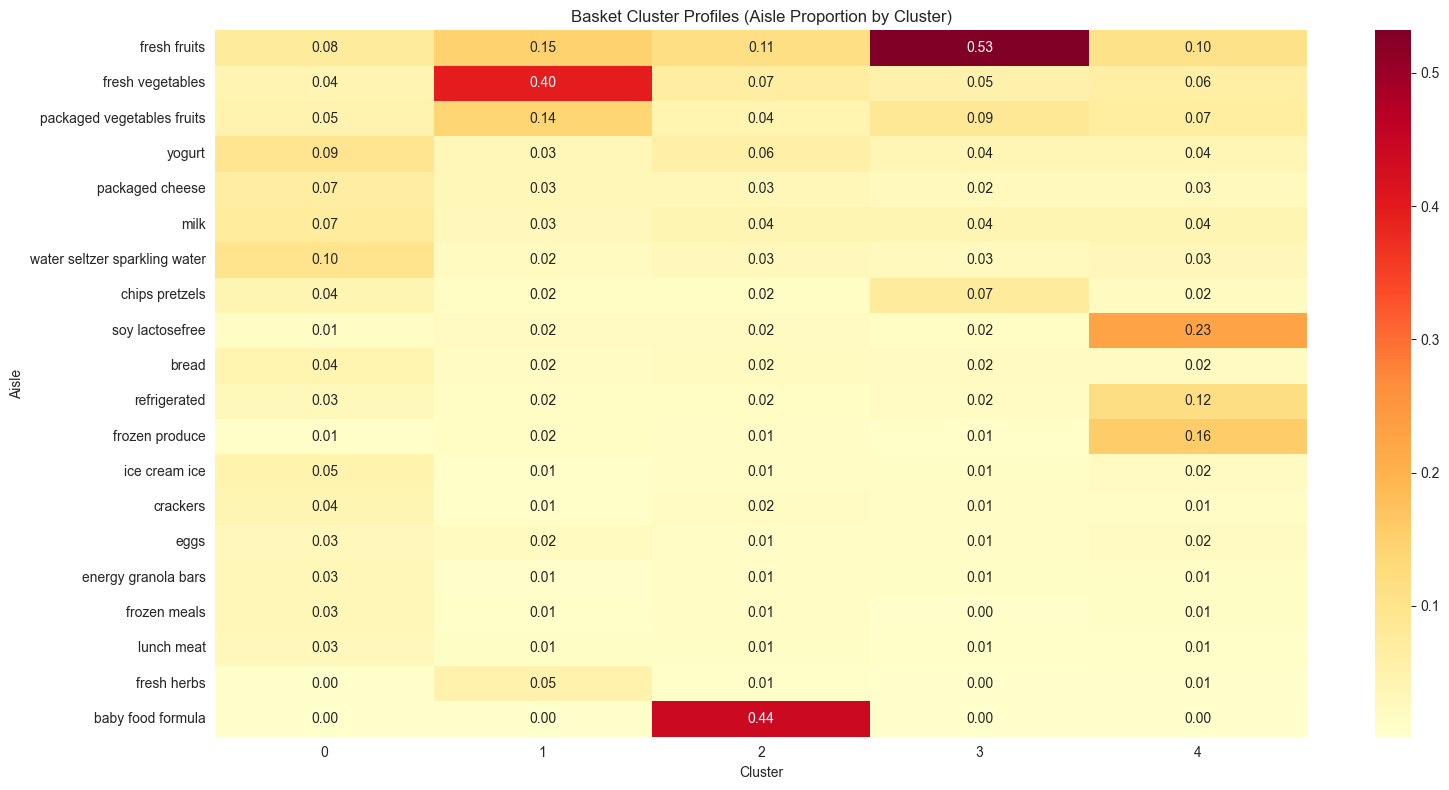

In [32]:
# Visualize cluster profiles as heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(cluster_profiles.T, cmap='YlOrRd', annot=True, fmt='.2f', ax=ax)
ax.set_title('Basket Cluster Profiles (Aisle Proportion by Cluster)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Aisle')
plt.tight_layout()
plt.show()

## 19. Weekend vs Weekday Basket Differences

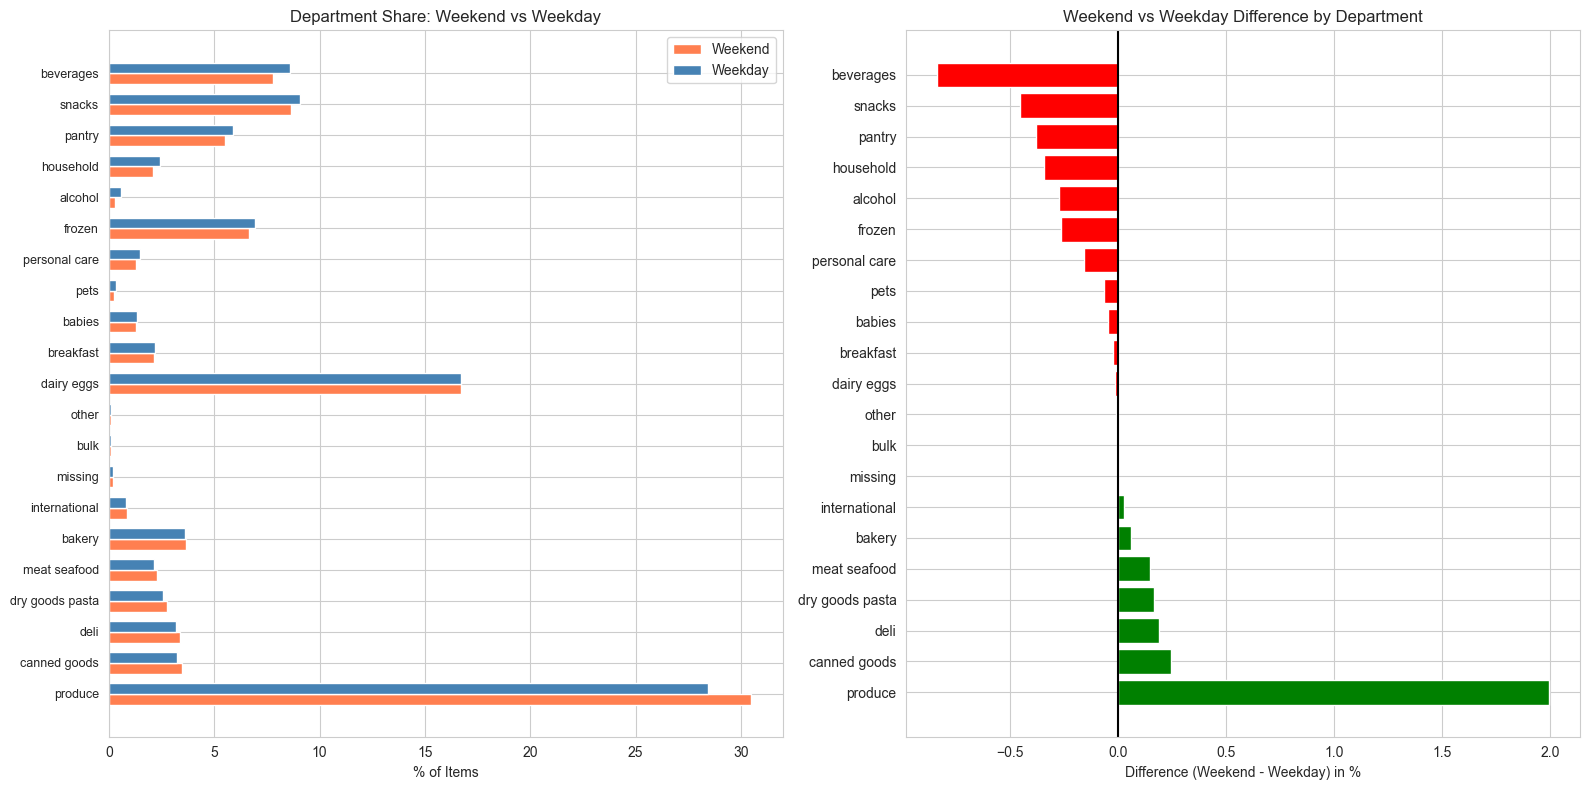


Departments with more weekend purchases:
department
produce            +2.00%
canned goods       +0.25%
deli               +0.19%
dry goods pasta    +0.17%
meat seafood       +0.15%
bakery             +0.06%
international      +0.03%
missing            +0.00%


In [33]:
# Weekend vs Weekday analysis
# order_dow: 0 = Saturday, 1 = Sunday, 2-6 = Monday-Friday (based on earlier analysis)
orders['is_weekend'] = orders['order_dow'].isin([0, 1])

# Sample orders for analysis
weekend_orders = orders[orders['is_weekend']]['order_id'].sample(50000, random_state=42)
weekday_orders = orders[~orders['is_weekend']]['order_id'].sample(50000, random_state=42)

weekend_items = op_prior[op_prior['order_id'].isin(weekend_orders)].merge(
    prod_full[['product_id', 'department', 'aisle']], on='product_id'
)
weekday_items = op_prior[op_prior['order_id'].isin(weekday_orders)].merge(
    prod_full[['product_id', 'department', 'aisle']], on='product_id'
)

# Compare department distribution
weekend_dept = weekend_items['department'].value_counts(normalize=True).rename('weekend')
weekday_dept = weekday_items['department'].value_counts(normalize=True).rename('weekday')
dept_dow = pd.concat([weekend_dept, weekday_dept], axis=1).fillna(0)
dept_dow['diff'] = dept_dow['weekend'] - dept_dow['weekday']
dept_dow = dept_dow.sort_values('diff', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1: Weekend vs Weekday by department
x = np.arange(len(dept_dow))
width = 0.35
axes[0].barh(x - width/2, dept_dow['weekend']*100, width, label='Weekend', color='coral')
axes[0].barh(x + width/2, dept_dow['weekday']*100, width, label='Weekday', color='steelblue')
axes[0].set_yticks(x)
axes[0].set_yticklabels(dept_dow.index, fontsize=9)
axes[0].set_xlabel('% of Items')
axes[0].set_title('Department Share: Weekend vs Weekday')
axes[0].legend()

# Chart 2: Difference (weekend - weekday)
colors = ['green' if v > 0 else 'red' for v in dept_dow['diff']]
axes[1].barh(dept_dow.index, dept_dow['diff']*100, color=colors)
axes[1].axvline(x=0, color='black', linestyle='-')
axes[1].set_xlabel('Difference (Weekend - Weekday) in %')
axes[1].set_title('Weekend vs Weekday Difference by Department')

plt.tight_layout()
plt.show()

print("\nDepartments with more weekend purchases:")
print(dept_dow[dept_dow['diff'] > 0]['diff'].apply(lambda x: f"+{x*100:.2f}%").to_string())

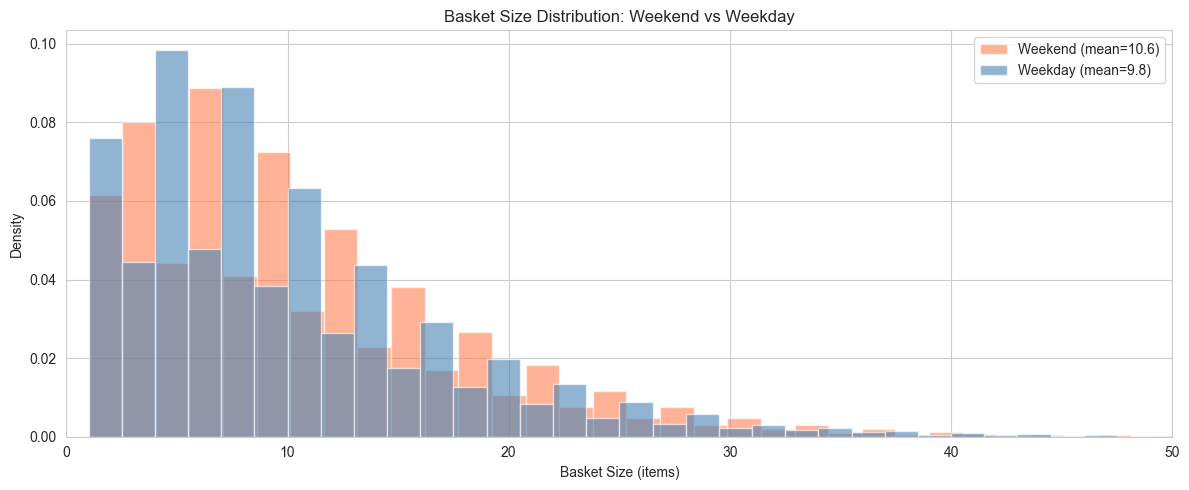

Weekend mean basket size: 10.61
Weekday mean basket size: 9.81
Difference: 0.80 items


In [34]:
# Basket size comparison: Weekend vs Weekday
weekend_basket_sizes = op_prior[op_prior['order_id'].isin(weekend_orders)].groupby('order_id').size()
weekday_basket_sizes = op_prior[op_prior['order_id'].isin(weekday_orders)].groupby('order_id').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(weekend_basket_sizes.values, bins=50, alpha=0.6, label=f'Weekend (mean={weekend_basket_sizes.mean():.1f})', color='coral', density=True)
ax.hist(weekday_basket_sizes.values, bins=50, alpha=0.6, label=f'Weekday (mean={weekday_basket_sizes.mean():.1f})', color='steelblue', density=True)
ax.set_xlabel('Basket Size (items)')
ax.set_ylabel('Density')
ax.set_title('Basket Size Distribution: Weekend vs Weekday')
ax.set_xlim(0, 50)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Weekend mean basket size: {weekend_basket_sizes.mean():.2f}")
print(f"Weekday mean basket size: {weekday_basket_sizes.mean():.2f}")
print(f"Difference: {weekend_basket_sizes.mean() - weekday_basket_sizes.mean():.2f} items")

## 20. Deep Basket Analysis Summary

### Key Findings for Planogram/Shelf Placement:

1. **High-Affinity Product Pairs**: Bananas and organic produce dominate co-purchases. These high-velocity items should anchor produce sections.

2. **Aisle Adjacency Recommendations**: Fresh fruits, fresh vegetables, and packaged vegetables show highest co-occurrence and should be adjacent in store layout.

3. **Reorder Patterns**: Dairy eggs (67%) and beverages (65%) have highest reorder rates - these are habit-driven categories requiring consistent shelf placement and stock availability.

4. **Cross-Sell Opportunities**: Association rules reveal strong lift between organic produce items and between fresh fruits and dairy items.

5. **Basket Archetypes**: Clustering reveals distinct shopper missions - produce-focused, dairy-focused, and mixed baskets. Store layouts can optimize for dominant mission types.

6. **Weekend vs Weekday**: Weekend baskets are slightly larger with more produce and dairy purchases - consider weekend staffing and promotions for these categories.